In [1]:
import os
import json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(
    context="paper",
    style="white",
    palette="colorblind",
    font="DejaVu Sans",
    font_scale=1.25,
)

In [2]:
def bin_metrics(x_values, metric_values, bins):
    binned, _ = np.histogram(x_values, bins=bins, weights=metric_values)
    counts, _ = np.histogram(x_values, bins=bins)
    
    avg = np.divide(binned, counts, where=counts > 0, 
                    out=np.full_like(binned, np.nan, dtype=float))
    return avg

def compute_binned_trajectories(metric_list, bins, metric_type='sum', use_logit=False, include_initial=True):
    binned_list = []
    for i in range(len(metric_list)):
        binned = bin_metrics(metric_list[i]['ratio'].cpu().numpy(),
                            metric_list[i][metric_type].cpu().numpy(), bins)
        
        if include_initial:
            initial_value = metric_list[i][metric_type][0].cpu().numpy()
            binned = np.concatenate([[initial_value], binned])
        
        binned_list.append(binned)
    return binned_list

def plot_trajectories(ax, centers, binned_list, color, label="Euclidean Steering", 
                      ylim=None, show_each=False, style='filled', include_initial=True):
    if show_each:
        for binned in binned_list:
            valid = ~np.isnan(binned)
            if np.any(valid):
                x_plot = centers[valid] if not include_initial else np.concatenate([[centers[0] - (centers[1] - centers[0])/2], centers])[valid]
                ax.plot(x_plot, binned[valid], color=color, 
                       alpha=0.3, linewidth=0.5)
    
    with np.errstate(all='ignore'):
        mean = np.nanmean(np.array(binned_list), axis=0)
        sem = np.nanstd(np.array(binned_list), axis=0) / np.sqrt(len(binned_list))
        valid_mean = ~np.isnan(mean)
        
        if not np.any(valid_mean):
            return None
        
        if include_initial:
            x_coords = np.concatenate([[centers[0] - (centers[1] - centers[0])/2], centers])
            x_valid = x_coords[valid_mean]
        else:
            x_valid = centers[valid_mean]
            
        y_valid = mean[valid_mean]
        err_valid = sem[valid_mean]
        
        if style == 'filled':
            line = ax.plot(x_valid, y_valid, label=label, color=color, 
                          linewidth=2, zorder=3)[0]
            ax.fill_between(x_valid, y_valid - err_valid, y_valid + err_valid,
                           color=color, alpha=0.2, linewidth=0, zorder=2)
            
        elif style == 'gradient':
            line = ax.plot(x_valid, y_valid, label=label, color=color, 
                          linewidth=2, zorder=3)[0]
            for alpha_mult in [1.0, 0.7, 0.3]:
                ax.fill_between(x_valid, 
                               y_valid - err_valid * (1/alpha_mult), 
                               y_valid + err_valid * (1/alpha_mult),
                               color=color, alpha=alpha_mult * 0.2, 
                               linewidth=0, zorder=2)
        
        elif style == 'errorbar':
            line = ax.errorbar(x_valid, y_valid, yerr=err_valid, 
                             label=label, color=color, linewidth=2,
                             capsize=5, capthick=2, 
                             marker='o', markersize=4, markeredgewidth=1.5,
                             markerfacecolor='white', markeredgecolor=color,
                             elinewidth=1.5, alpha=0.9, zorder=3)
    
    if ylim is not None:
        ax.set_ylim(ylim)
    
    ax.grid(alpha=0.3, linestyle='--', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return line

In [3]:
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FixedLocator, FixedFormatter
from matplotlib.ticker import FormatStrFormatter
from pyparsing import col

def create_combined_plot_lists(llm_list, object_list, coco_list, direction_name, use_logit=False, style='filled'):
    fig = plt.figure(figsize=(7, 7))
    gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.3)
    
    metrics = [
        ('sum', "Counterfactual Sum"),
        ('fkl', "KL divergence"),
        ('rank_diff', "Rank Difference")
    ]
    
    num_bins = 10
    if use_logit:
        bins = np.linspace(-15, 15, num_bins + 1)
        centers = 0.5 * (bins[:-1] + bins[1:])
    else:
        bins = np.linspace(0, 1, num_bins + 1)
        centers = 0.5 * (bins[:-1] + bins[1:])

    # LLM plots
    gs_llm = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[0], hspace=0.3)
    
    for row, (metric_type, ylabel) in enumerate(metrics):
        ylim = (0, 1) if metric_type == 'sum' else None
        ax = fig.add_subplot(gs_llm[row, 0])
        
        llm_e_binned = compute_binned_trajectories(llm_list[direction_name]['e'], bins, 
                                                   metric_type=metric_type, use_logit=use_logit)
        llm_m_binned = compute_binned_trajectories(llm_list[direction_name]['m'], bins, 
                                                   metric_type=metric_type, use_logit=use_logit)
        
        line1 = plot_trajectories(ax, centers, llm_e_binned, color='C0', 
                                 label="Euclidean Steering", ylim=ylim, style=style)
        line2 = plot_trajectories(ax, centers, llm_m_binned, color='C3', 
                                 label="Dual Steering", ylim=ylim, style=style)
        

        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        ax.set_ylabel(ylabel, labelpad=5)
        if row == 0:
            ax.set_title("LLM", fontsize=12, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.xaxis.set_major_locator(FixedLocator([0, 0.5, 1.0]))
        ax.xaxis.set_major_formatter(FixedFormatter(['0', '0.5', '1']))
    
    # object plots
    gs_object = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[1], hspace=0.3)
    
    for row, (metric_type, ylabel) in enumerate(metrics):
        ylim = (0, 1) if metric_type == 'sum' else None
        ax = fig.add_subplot(gs_object[row, 0])
        
        object_e_binned = compute_binned_trajectories(object_list[direction_name]['e'], bins, 
                                                    metric_type=metric_type, use_logit=use_logit)
        object_m_binned = compute_binned_trajectories(object_list[direction_name]['m'], bins, 
                                                    metric_type=metric_type, use_logit=use_logit)
        
        plot_trajectories(ax, centers, object_e_binned, color='C0', 
                         label="Euclidean Steering", ylim=ylim, style=style)
        plot_trajectories(ax, centers, object_m_binned, color='C3', 
                         label="Dual Steering", ylim=ylim, style=style)

        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        if row == 0:
            ax.set_title("CLIP (Object)", fontsize=12, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.xaxis.set_major_locator(FixedLocator([0, 0.5, 1.0]))
        ax.xaxis.set_major_formatter(FixedFormatter(['0', '0.5', '1']))

    # COCO plots
    gs_coco = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[2], hspace=0.3)
    
    for row, (metric_type, ylabel) in enumerate(metrics):
        ylim = (0, 1) if metric_type == 'sum' else None
        ax = fig.add_subplot(gs_coco[row, 0])
        
        coco_e_binned = compute_binned_trajectories(coco_list[direction_name]['e'], bins, 
                                                    metric_type=metric_type, use_logit=use_logit)
        coco_m_binned = compute_binned_trajectories(coco_list[direction_name]['m'], bins, 
                                                    metric_type=metric_type, use_logit=use_logit)
        
        plot_trajectories(ax, centers, coco_e_binned, color='C0', 
                         label="Euclidean Steering", ylim=ylim, style=style)
        plot_trajectories(ax, centers, coco_m_binned, color='C3', 
                         label="Dual Steering", ylim=ylim, style=style)

        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        if row == 0:
            ax.set_title("CLIP (COCO)", fontsize=12, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.xaxis.set_major_locator(FixedLocator([0, 0.5, 1.0]))
        ax.xaxis.set_major_formatter(FixedFormatter(['0', '0.5', '1']))

    # Add common labels and legend
    fig.text(0.5, 0.03, r"$P(W=1\mid \lambda_t)$", ha='center')
    handles = [line1, line2]
    labels = ["Euclidean Steering", "Dual Steering"]
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2)
    
    plt.savefig(f'figures/metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

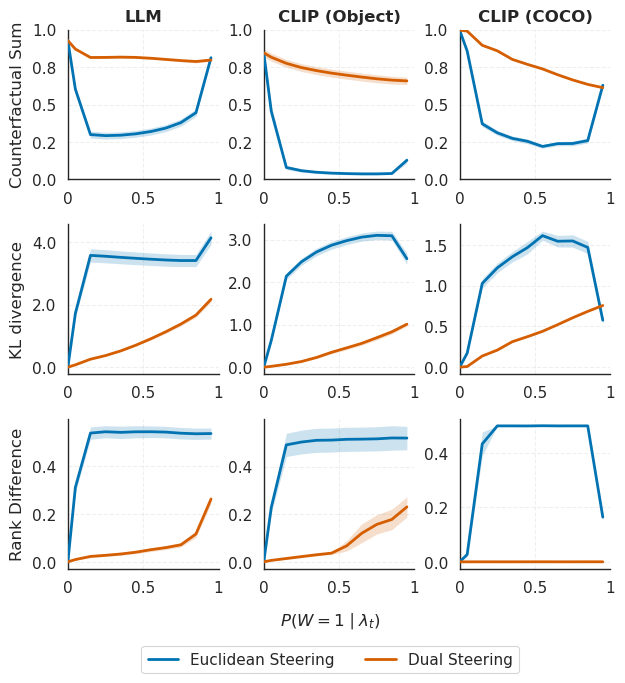

In [ ]:
llm_base_path = "LLM_BASE_PATH"
clip_base_path = "CLIP_BASE_PATH"

concept_name = "verb_en_fr"
llm_list = torch.load(os.path.join(llm_base_path, f"{concept_name}/test_steering_metrics.pt"),
                      weights_only=False)

target_concept = "color"
value0, value1 =  "yellow", "green"
object_list = torch.load(os.path.join(clip_base_path, f"{target_concept}_{value0}_to_{value1}.pt"),
                    weights_only=False)

coco_concept = "carrot_broccoli"
coco_list = torch.load(os.path.join(clip_base_path, f"{coco_concept}.pt"),
                       weights_only=False)

create_combined_plot_lists(llm_list, object_list, coco_list, "dual_md", use_logit=False, style='filled')

In [5]:
from matplotlib.ticker import FormatStrFormatter
def show_all_experiments(llm_experiments, object_experiments, coco_experiments,
                         direction_names, direction_labels = None,
                        metric_type='sum', ylabel="Counterfactual Sum", use_logit=False,
                        style = "filled"):
    
    if direction_labels is None:
        direction_labels = {name: name for name in direction_names}
    
    fig, axes = plt.subplots(4, 3, figsize=(12, 12))
    
    num_bins = 10
    bins = np.linspace(0,1, num_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    ylim = (0, 1) if metric_type == 'sum' else None
    colors = ['C2', 'C1', 'C0', 'C3', 'C4', 'C5', 'C6']
    
    all_handles = []
    all_labels = []
    legend_created = False

    all_experiments = [llm_experiments, object_experiments, coco_experiments]

    for col in range(3):
        if col == 0:
            current_experiments = llm_experiments
        elif col == 1:
            current_experiments = object_experiments
        else:
            current_experiments = coco_experiments
        
        
        n_exp = len(current_experiments)
        for row in range(4):
            ax = axes[row, col]
            if row >= n_exp:
                ax.set_visible(False)
                continue
            
            exp_list, exp_title = current_experiments[row]
            
            for idx, dir_name in enumerate(direction_names):
                color_e = colors[idx * 2]
                color_m = colors[idx * 2 + 1]

                exp_e_binned = compute_binned_trajectories(exp_list[dir_name]['e'], bins, metric_type=metric_type, use_logit=use_logit)
                exp_m_binned = compute_binned_trajectories(exp_list[dir_name]['m'], bins, metric_type=metric_type, use_logit=use_logit)
                line1 = plot_trajectories(
                    ax, centers, exp_e_binned, color=color_e, 
                    label=f"Euclidean Steering ({direction_labels[dir_name]})", ylim=ylim, 
                    style = style
                )
                line2 = plot_trajectories(
                    ax, centers, exp_m_binned, color=color_m, 
                    label=f"Dual Steering ({direction_labels[dir_name]})", ylim=ylim,
                    style = style
                )

                if not legend_created:
                    if line1 is not None:
                        all_handles.append(line1)
                        all_labels.append(f"Euclidean Steering ({direction_labels[dir_name]})")
                    if line2 is not None:
                        all_handles.append(line2)
                        all_labels.append(f"Dual Steering ({direction_labels[dir_name]})")
            
            legend_created = True
            if col == 0:
                ax.set_title(f"LLM ({exp_title})", fontsize=12, fontweight='bold')
            elif col == 1:
                ax.set_title(f"Object ({exp_title})", fontsize=12, fontweight='bold')
            else:
                ax.set_title(f"COCO ({exp_title})", fontsize=12, fontweight='bold')
    
    
    fig.text(0.5, -0.02, r"$P(W=1\mid \lambda_t)$", ha='center', fontsize=15)
    fig.text(-0.02, 0.5, ylabel, va='center', rotation='vertical', fontsize=15)
    
    # Add shared legend
    fig.legend(all_handles, all_labels, loc='lower center', 
              bbox_to_anchor=(0.5, -0.1), ncol=min(len(all_handles)/2, 4), fontsize=13)
    
    plt.tight_layout()
    
    # Save figure
    save_name = f'all_experiments_{metric_type}.png'
    plt.savefig(f'figures/{save_name}', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
llm_concept_names = ["verb_en_fr", "verb_ing", "verb_past", "verb_third"]
llm_titles = {"verb_en_fr": "English to French",
              "verb_ing": "Verb to -ing",
              "verb_past": "Verb to Past",
              "verb_third": "Verb to 3rd Person"}
llm_experiments = []
for concept in llm_concept_names:
    llm_data = torch.load(os.path.join(llm_base_path, f"{concept}/test_steering_metrics.pt"), weights_only=False)
    llm_experiments.append((llm_data, llm_titles[concept]))


object_concept_names = [
    ["color", "yellow", "green", "Yellow to Green"],
    ["color", "red", "green", "Red to Green"],
    ["shape", "squares", "triangles", "Squares to Triangles"],
    ["shape", "squares", "circles", "Squares to Circles"]
]           
object_experiments = []
for concept, val0, val1, title in object_concept_names:
    object_data = torch.load(os.path.join(clip_base_path, f"{concept}_{val0}_to_{val1}.pt"), weights_only=False)
    object_experiments.append((object_data, title))


coco_concept_names = ["carrot_broccoli", "broccoli_carrot", "traffic_light_fire_hydrant",  "cat_dog"]
concept_titles = {"cat_dog": "Cat to Dog",
                  "dog_cat": "Dog to Cat",
                  "fire_hydrant_traffic_light": "Fire Hydrant to Traffic Light",
                  "traffic_light_fire_hydrant": "Traffic Light to Fire Hydrant",
                  "carrot_broccoli": "Carrot to Broccoli",
                  "broccoli_carrot": "Broccoli to Carrot"}
coco_experiments = []
for concept in coco_concept_names:
    coco_data = torch.load(os.path.join(clip_base_path, f"{concept}.pt"), weights_only=False)
    coco_experiments.append((coco_data, concept_titles[concept]))


direction_names = ["primal_md", "dual_md"]
direction_labels = {"primal_md": "Primal MD", "dual_md": "Dual MD"}

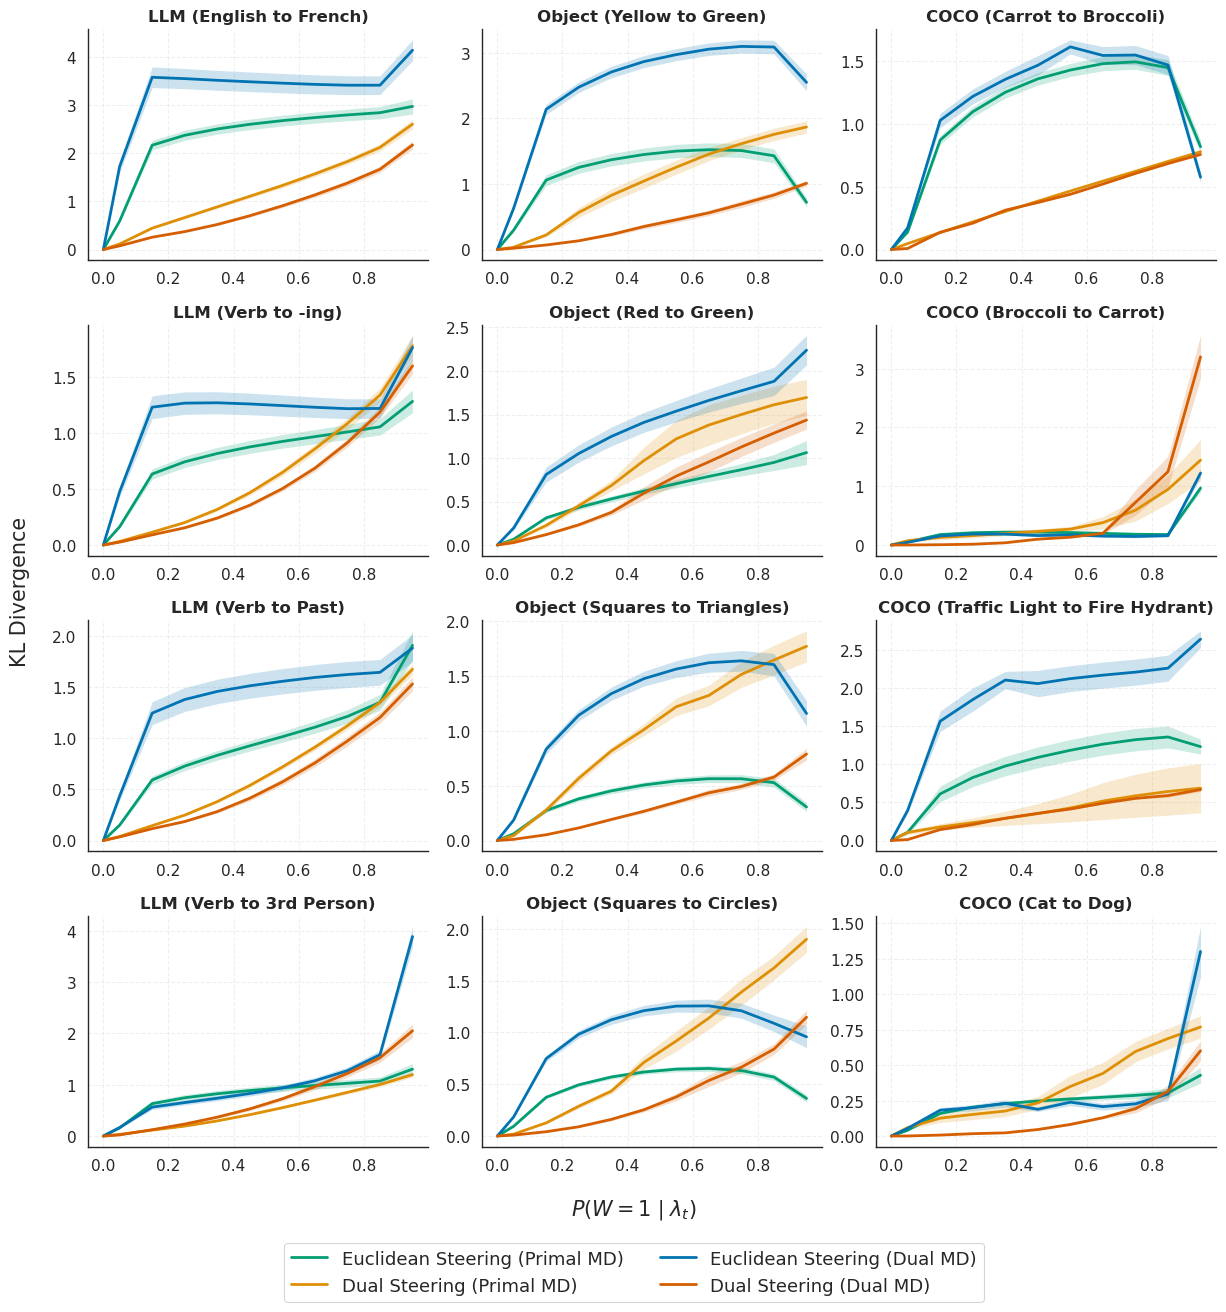

In [7]:
show_all_experiments(llm_experiments, object_experiments, coco_experiments,
                     direction_names, direction_labels,
                     metric_type='fkl', ylabel="KL Divergence")

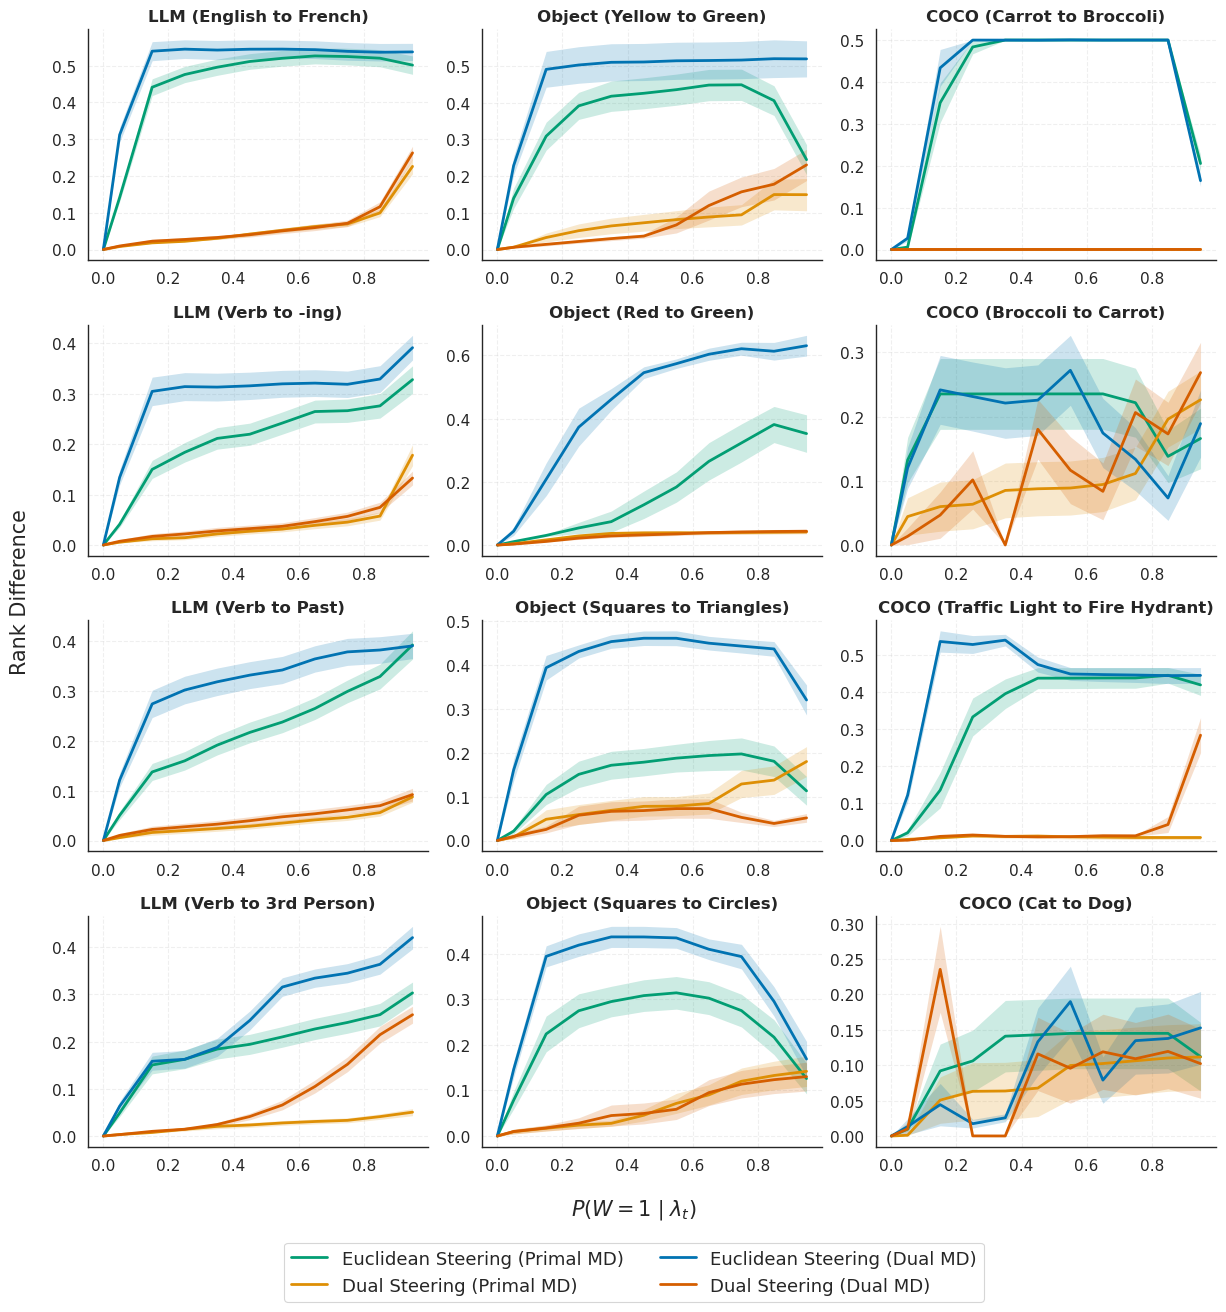

In [8]:
show_all_experiments(llm_experiments, object_experiments, coco_experiments,
                     direction_names, direction_labels,
                     metric_type='rank_diff', ylabel="Rank Difference")

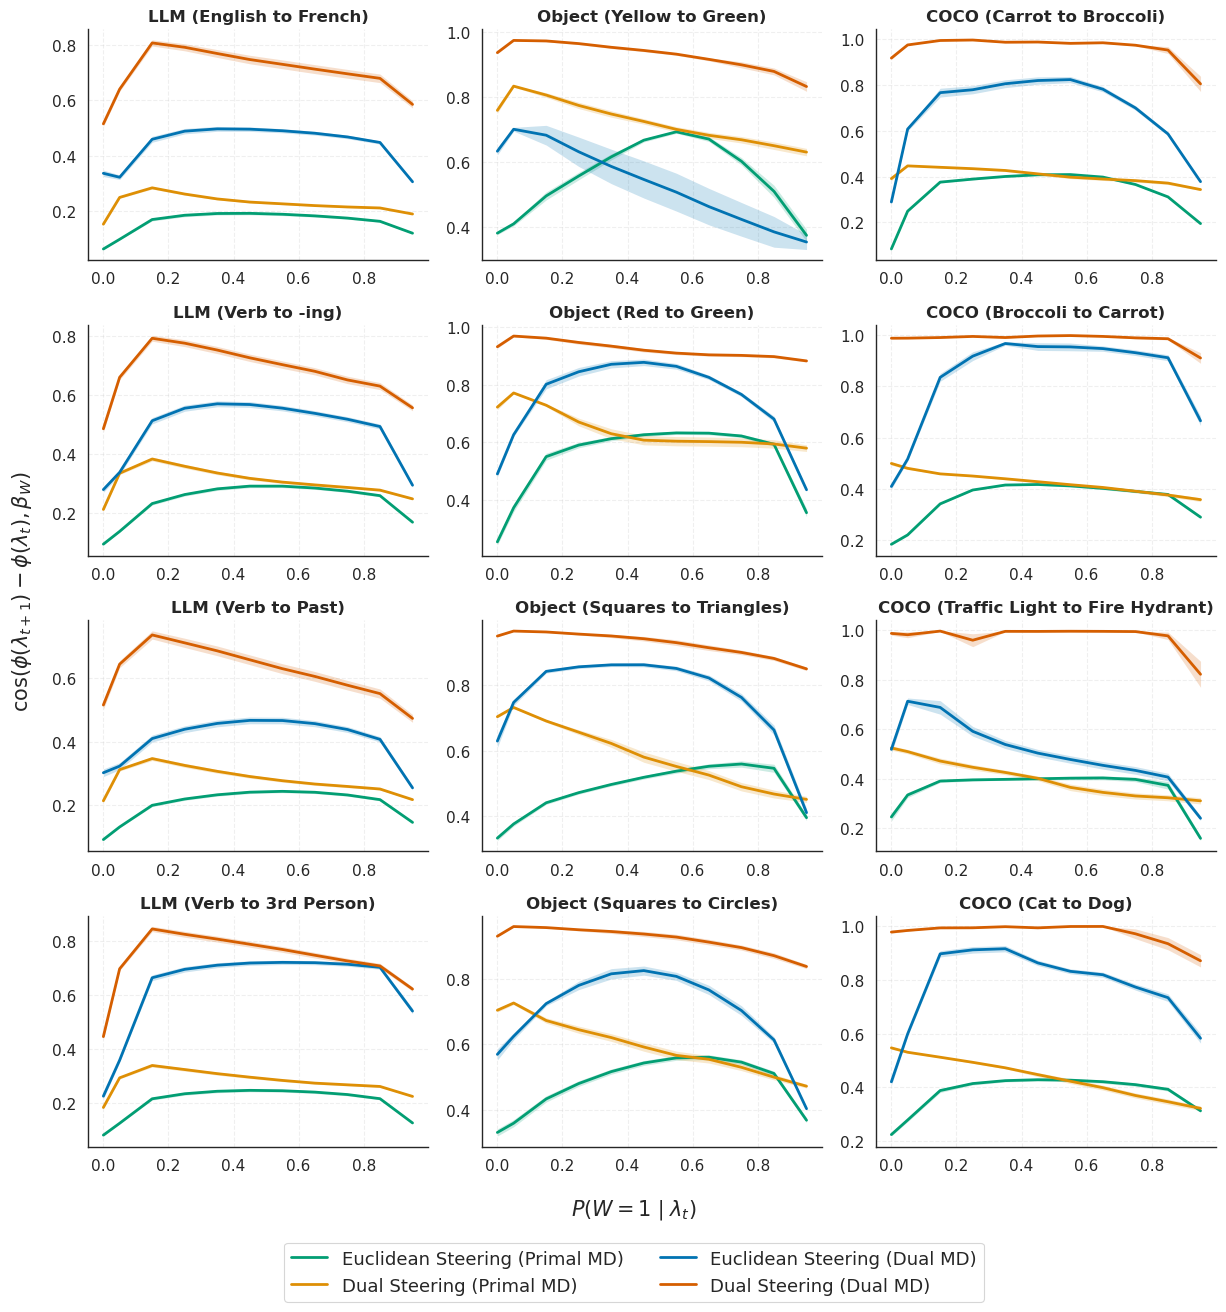

In [9]:
show_all_experiments(llm_experiments, object_experiments, coco_experiments,
                     direction_names, direction_labels,
                     metric_type='cos', ylabel=r"$\cos(\phi(\lambda_{t+1}) - \phi(\lambda_{t}), \beta_W)$")

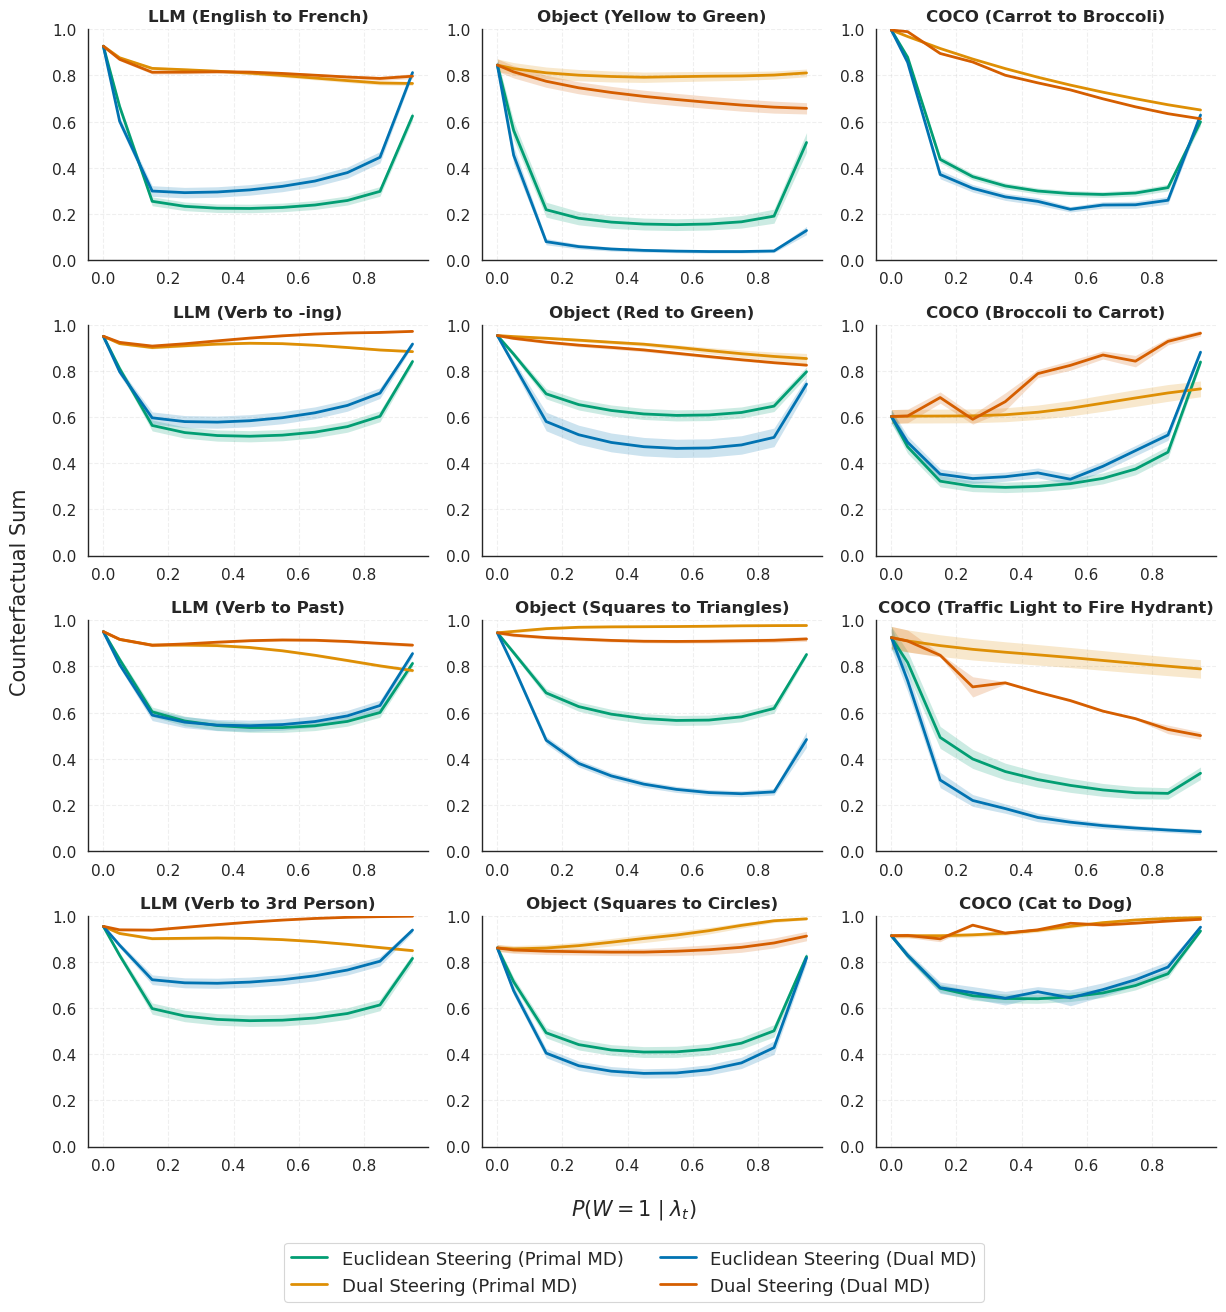

In [10]:
show_all_experiments(llm_experiments, object_experiments, coco_experiments,
                     direction_names, direction_labels,
                     metric_type='sum', ylabel="Counterfactual Sum")